# Lab: Network Analysis I

In [1]:
import otter
grader = otter.Notebook("network-analysis.ipynb")

<!-- BEGIN QUESTION -->

#### **Question 1:** The Structure of Networks I
Based on the image below, answer the following questions. This time, you don't have to support your answers with code.

- 1.1 How many nodes and edges can you identify in the network? Please provide examples of both nodes and edges in your response.
- 1.2 Choose two paths from the network. Are any of these paths simple?
- 1.3 Does the network contain any cycles? If so, please provide two examples of cycles.

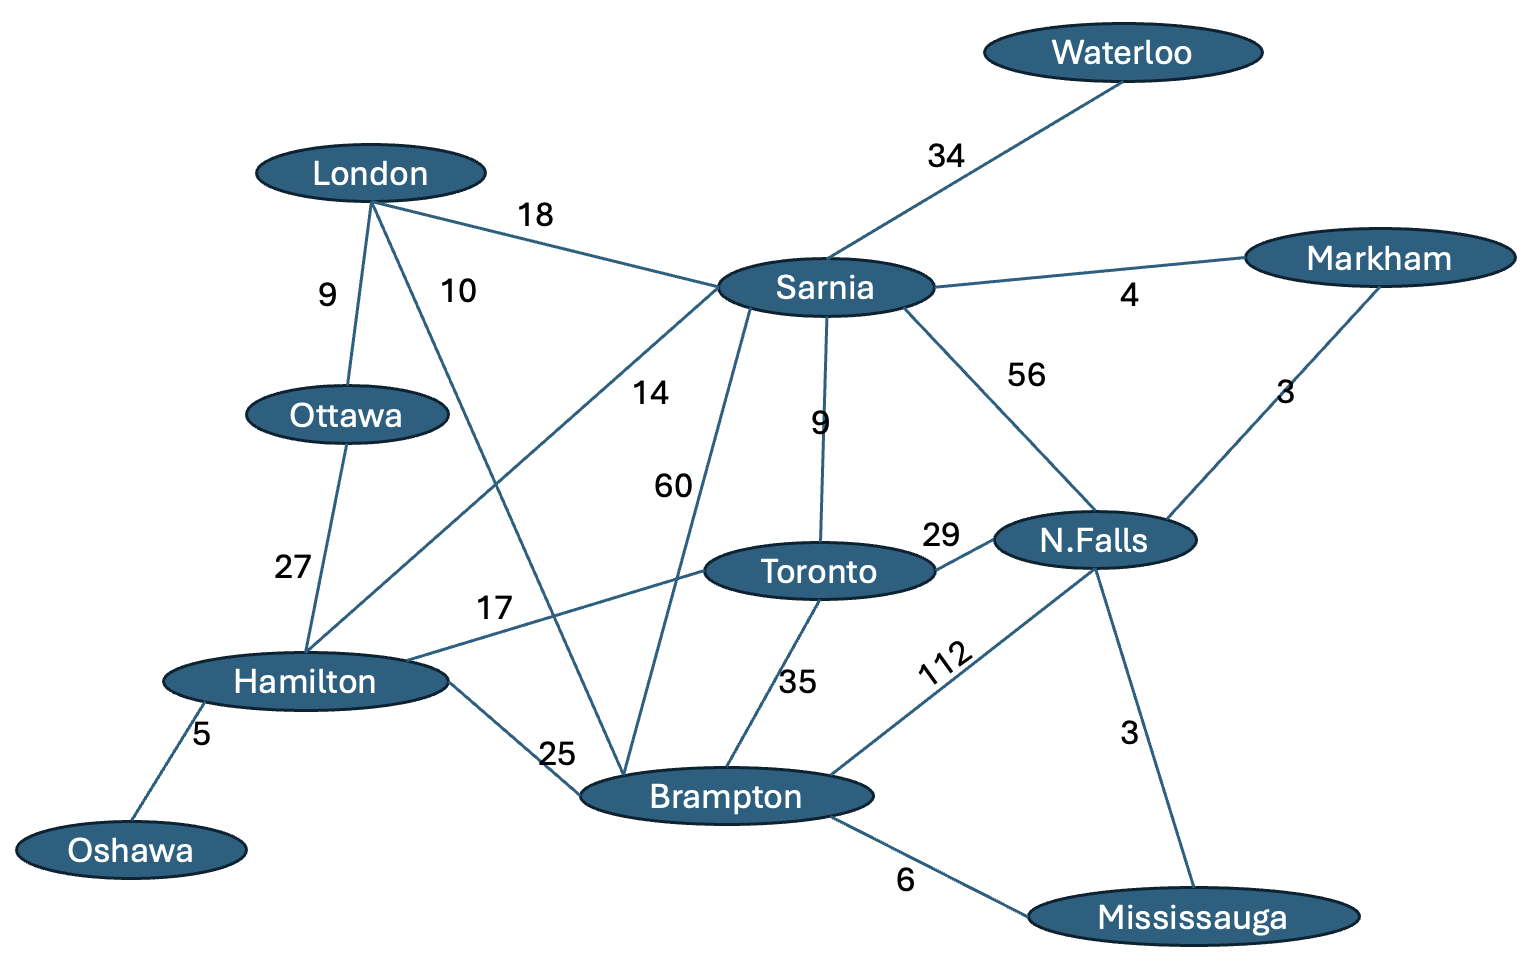

In [2]:
#1.1 How many nodes and edges can you identify in the network? Please provide examples of both nodes and edges in your response.

# NODES
# There are 11 nodes in the network
# Examples of nodes:
# - London  - Toronto   - Ottawa  - Hamilton  - Sarnia
# - Brampton  - Waterloo  - Markham  - Niagara Falls  - Mississauga  - Oshawa

# EDGES
# There are 18 edges in the network
# Examples of edges:
# 1. London-Ottawa (weight: 9)
# 2. Toronto-Sarnia (weight: 9)
# 3. Hamilton-Oshawa (weight: 5)
# 4. Brampton-Mississauga (weight: 6)

In [3]:
#1.2 Choose two paths from the network. Are any of these paths simple?

# Path 1: London -> Ottawa -> Hamilton -> Brampton
# This is a simple path because no node is visited more than once

# Path 2: Sarnia -> Toronto -> Brampton -> Hamilton -> Ottawa
# This is also a simple path because no node is visited more than once. Each node only appears once in the sequence

In [4]:
#1.3 Does the network contain any cycles? If so, please provide two examples of cycles.

# Yes, the network contains cycles. Examples:

# Cycle 1: London -> Sarnia -> Toronto -> Hamilton -> Ottawa -> London
# This cycle returns to the starting node at the end (London)

# Cycle 2: Sarnia -> Toronto -> Niagara Falls -> Markham -> Sarnia
# This cycle also visits different nodes but returns to the starting node (Sarnia)

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

#### **Question 2:** The Structure of Networks II
Looking at the graph in Question 1, answer in a comment the following questions. You don't have to support your answers with code. 
 - 2.1 What is the degree of the Toronto, Sarnia, and Markham nodes? 
 - 2.2 What is the weighted degree of London?
 - 2.3 What is the classification of this graph, according to the direction of the edges? Explain.
 - 2.4 What is the classification of this graph, according to the information of the edges? Explain.

In [5]:
#2.1 What is the degree of the Toronto, Sarnia, and Markham nodes?

# The degree of Toronto node is 4
# Connected to: Sarnia, Niagara Falls, Brampton, Hamilton

# The degree of Sarnia node is 6
# Connected to: London, Toronto, Waterloo, Markham, Niagara Falls, Brampton

# The degree of Markham node is 2
# Connected to: Sarnia and Niagara Falls

In [6]:
#2.2 What is the weighted degree of London?

# The weighted degree of London is 37
# Connected to: Ottawa, Sarnia, Brampton
# London-Ottawa: 9
# London-Sarnia: 18
# London-Brampton: 10

In [7]:
#2.3 What is the classification of this graph, according to the direction of the edges? Explain.

# This is an undirected graph.
# This is because the edges have no arrows and all connections between nodes are bidirectional. For example, you can go from London to Ottawa, but you can also go from Ottawa to London using the same edge

In [8]:
#2.4 What is the classification of this graph, according to the information of the edges? Explain.

# This is a weighted graph.
# This is because each edge carries information.
# Each edge is labelled and has a numerical value (weight) that represents the distance between the cities.

<!-- END QUESTION -->

#### **Question 3:** Complete the code. 
The network in `data.csv` represents the distances (in kilometres) between a group of friends.
Complete the following code to load the network, following the instructions in the comments.  

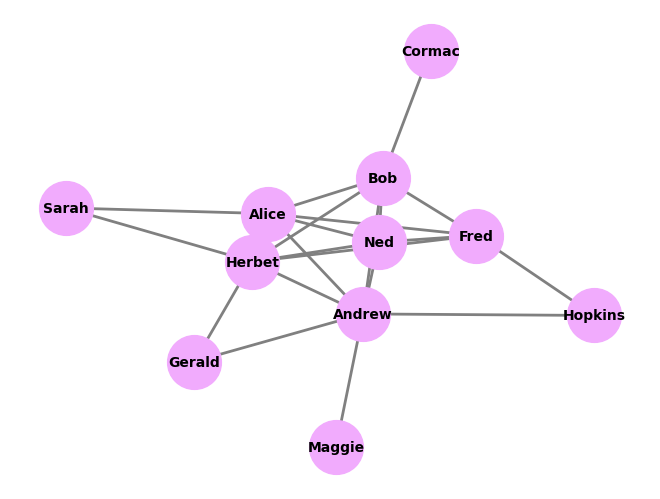

In [9]:
# Import pandas, and networkx.
import pandas as pd
import networkx as nx

# Read the CSV file `data.csv` into a DataFrame object named `df`.
df = pd.read_csv('data.csv')

# Create a graph object (G) using the information in the file (Source, Target, and Weight).
G = nx.from_pandas_edgelist(df, 'Source', 'Target', 'Weight')

# Draw a graph. Add colours, labels, and font size of your preference. 
nx.draw(G,
        with_labels=True,
        node_color='#F1ABFD',
        node_size=1500,
        font_size=10,
        font_weight='bold',
        edge_color='gray',
        width=2)

In [10]:
grader.check("q3")

q3 results: All test cases passed!
q3 - 1 message: Great! Your code passed this test.

#### **Question 4:** Which friends are directly connected to Herbet? 
 - Directly connected means that there is only one edge between them in the graph. They are neighbours of Herbert. 
 - Support your response with code. 
 - Add the list of names to a variable named `herbet_connections`. 

In [11]:
# find all neighbours (directly connected nodes) of Herbet
herbet_connections = list(G.neighbors('Herbet')) # store as a list using list()

# display the results
print('Friends directly connected to Herbet:')
print(herbet_connections)

Friends directly connected to Herbet:
['Andrew', 'Gerald', 'Sarah', 'Alice', 'Bob', 'Ned', 'Fred']


In [12]:
grader.check("q4")

q4 results: All test cases passed!
q4 - 1 message: Great! Your code passed this test.

#### **Question 5:** Calculate the weighted degree centrality of all the friends in the graph. 

- Store the results in a DataFrame called `df5`, with person names as the index and the weighted degree centrality values in a column named `wdegree`.
- Sort the DataFrame with `wdegree` in descending order
- Show `df5` in the cell output.  

In [13]:
# compute the degree in the network and put them in a dictionary
w_degrees = dict(nx.degree(G, weight='Weight'))

# add the weighted degree as a network attribute
nx.set_node_attributes(G, name='wdegree', values=w_degrees)

# create a pandas dataframe from the weighted degree data
df5 = pd.DataFrame(G.nodes(data='wdegree'), columns=['node', 'wdegree'])
df5 = df5.set_index('node') # set node as the index
df5 = df5.sort_values(by='wdegree', ascending=False) # sort in descending order (highest to lowest)

df5 # display the dataframe

,wdegree
node,
Herbet,244
Alice,164
Andrew,144
Bob,107
Fred,91
Maggie,51
Ned,33
Hopkins,27
Sarah,9


In [14]:
grader.check("q5")

q5 results: All test cases passed!
q5 - 1 message: Great! Your code passed this test.

<!-- BEGIN QUESTION -->

#### **Question 6:** Comparing nodes: 
- Select any two friends (nodes) in the network loaded in Question 4. 
- Compare them by addressing how many neighbours each person has. How far away do they live from their neighbours (based on their weighted degrees)?
- What might these differences suggest about their communication? Assume that the communication cost is proportional to geographical distance.
- It is not mandatory to use code here, but your answers must be coherent and accurate, according to the graph loaded in Q4. 

In [15]:
# choose two friends to compare
friend1 = 'Alice'
friend2 = 'Sarah'

metric = 'km'

# get neighbours for each friend
neighbors1 = list(G.neighbors(friend1))
neighbors2 = list(G.neighbors(friend2))

print(f'Comparing: {friend1} and {friend2} (in {metric})')

# display number of neighbours
print('\nNumber of Neighbors:')
print(f'{friend1} has {len(neighbors1)} neighbors: {neighbors1}')
print(f'{friend2} has {len(neighbors2)} neighbors: {neighbors2}')

# get weighted degrees for friend 1 and 2
w_degree1 = G.degree(friend1, weight='Weight')
w_degree2 = G.degree(friend2, weight='Weight')

print('\nWeighted Degrees:')
print(f"{friend1}'s weighted degree: {w_degree1}")
print(f"{friend2}'s weighted degree: {w_degree2}")

# calculate average distance to neighbours
# weighted degree divided by # of neighbours IF # of neighbours is not more than 0. ELSE, avg distance is 0

avg_distance1 = w_degree1 / (len(neighbors1) if len(neighbors1) > 0 else 0)
avg_distance2 = w_degree2 / (len(neighbors2) if len(neighbors2) > 0 else 0)

print('\nAverage Distance to Neighbors:')
print(f"{friend1}'s average distance to neighbors: {avg_distance1:.2f}{metric}") # .2f displays number with two decimal places
print(f"{friend2}'s average distance to neighbors: {avg_distance2:.2f}{metric}")

# show individual distances
print(f"\n{friend1}'s distance to each neighbor:")

for n in neighbors1:
    distance = G[friend1][n]['Weight'] # get distance (weight) between friend 1 and each neighbour
    print(f'  - {n}: {distance}{metric}')

print(f"\n{friend2}'s distance to each neighbor:")

for n in neighbors2:
    distance = G[friend2][n]['Weight'] # get distance (weight) between friend 2 and each neighbour
    print(f'  - {n}: {distance}{metric}')

print('\nQUESTION: What might these differences suggest about their communication?\nAssume that the communication cost is proportional to geographical distance.')

comm_cost1 = w_degree1
comm_cost2 = w_degree2

print(f'''
{friend1} has more communication options with 6 neighbors, but faces higher total communication costs ({comm_cost1}{metric}) compared to Sarah, who was minimal cost ({comm_cost2}{metric}) but is limited to two connections/neighbors.
Alice is more connected, but Sarah is more efficient in terms of distance-based communication costs.
''')


Comparing: Alice and Sarah (in km)

Number of Neighbors:
Alice has 6 neighbors: ['Andrew', 'Herbet', 'Sarah', 'Fred', 'Bob', 'Ned']
Sarah has 2 neighbors: ['Herbet', 'Alice']

Weighted Degrees:
Alice's weighted degree: 164
Sarah's weighted degree: 9

Average Distance to Neighbors:
Alice's average distance to neighbors: 27.33km
Sarah's average distance to neighbors: 4.50km

Alice's distance to each neighbor:
  - Andrew: 4km
  - Herbet: 112km
  - Sarah: 6km
  - Fred: 12km
  - Bob: 25km
  - Ned: 5km

Sarah's distance to each neighbor:
  - Herbet: 3km
  - Alice: 6km

QUESTION: What might these differences suggest about their communication?
Assume that the communication cost is proportional to geographical distance.

Alice has more communication options with 6 neighbors, but faces higher total communication costs (164km) compared to Sarah, who was minimal cost (9km) but is limited to two connections/neighbors.
Alice is more connected, but Sarah is more efficient in terms of distance-based c

<!-- END QUESTION -->

#### **Question 7:** Who is the friend most often found on the shortest routes connecting other friends in the network?
- Support your response with code by calculating the adequate centrality metric.
- Place the name of the person in the variable `result7`.

Suggestion:
- Create a dataframe `df7` with the betweenness centrality of all the nodes.
- Sort the Dataframe `df7` in descending order and get the top element.

In [16]:
# calculate betweeness centrality for all nodes (unweighted)
betweenness = nx.betweenness_centrality(G)

# create a dataframe with the betweeness centrality values
df7 = pd.DataFrame.from_dict(betweenness, orient='index', columns=['betweeness'])

# sort by betweeness centrality in descending order
df7 = df7.sort_values('betweeness', ascending=False)

result7 = df7.index[0] # get name of the person with highest betweeness centrality

print(f'The friend most often found on the shortest routes: {result7}')
df7 # display the dataframe

The friend most often found on the shortest routes: Andrew


,betweeness
Andrew,0.333333
Bob,0.208889
Herbet,0.175556
Alice,0.086667
Fred,0.066667
Hopkins,0.008889
Ned,0.008889
Maggie,0.000000
Gerald,0.000000
Sarah,0.000000


In [17]:
grader.check("q7")

q7 results: All test cases passed!
q7 - 1 message: Great! Your code passed this test.

<!-- BEGIN QUESTION -->

#### **Question 8:** 

Draw a network that represents the size of the nodes adjusted to the metric value you calculated in Question 7.  

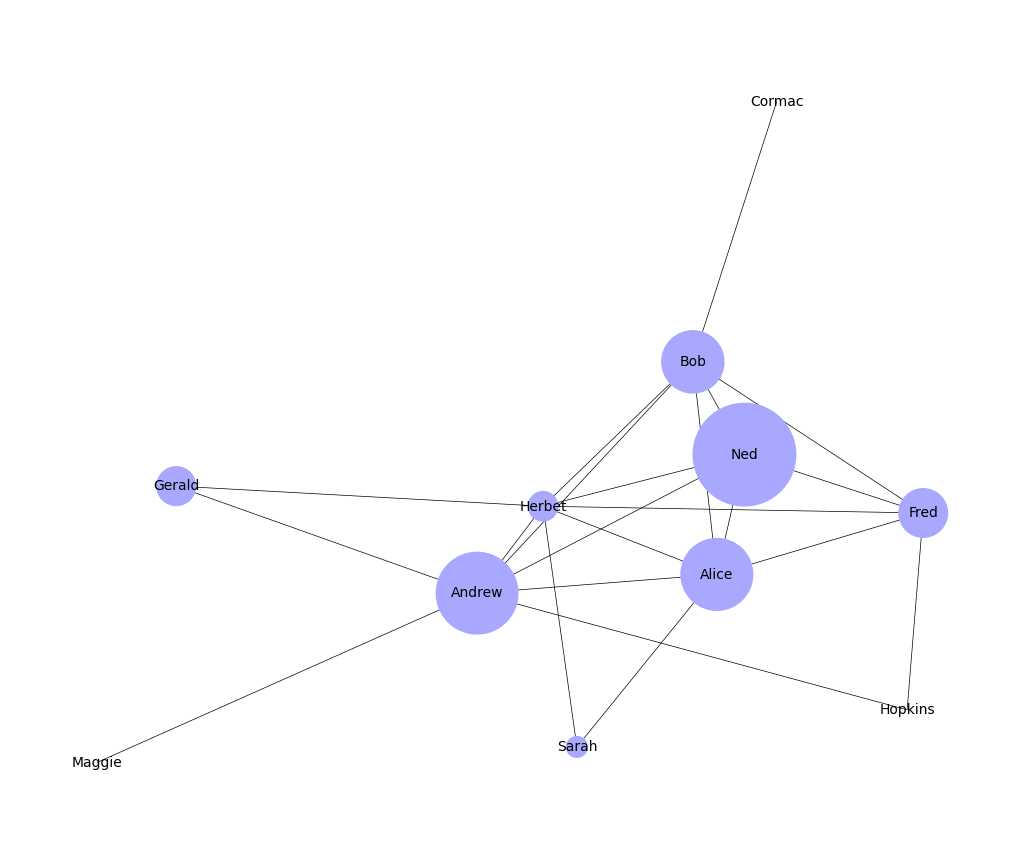

In [18]:
import matplotlib.pyplot as plt

# get betweeness centrality for each node (weighted)
betweenness = nx.betweenness_centrality(G, weight='Weight')

# determine the node size (12.3.4 in the lecture)
node_sizes = [v * 10000 for v in betweenness.values()]

# draw the network eith node sizes based on betweeness centrality
plt.figure(figsize=(10, 8))

# draw the graph
nx.draw(G,
        with_labels=True, # show labels
        node_size=node_sizes, # set node size to the variable storing the for loop
        node_color='#A8A8FF', # set custom color for nodes
        width=0.5, # width of lines
        font_size=10,) # font size of node labels

# add a title to the graph
plt.title('Network with Node Sizes Based on Betweenness Centrality')
plt.show() # show the graph

<!-- END QUESTION -->

# C. Testing 
To double-check your work, the cell below will rerun all of the autograder tests.

In [19]:
grader.check_all()

q3 results: All test cases passed!
q3 - 1 message: Great! Your code passed this test.

q4 results: All test cases passed!
q4 - 1 message: Great! Your code passed this test.

q5 results: All test cases passed!
q5 - 1 message: Great! Your code passed this test.

q7 results: All test cases passed!
q7 - 1 message: Great! Your code passed this test.